# Hidden Markov Models (forcasting weather)

## Importing,Cleaning and Defining Test/Train Split  

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('seattle.csv',)

# Cleaning the data 

# Removing empty cells as this is weather data
df = df.dropna()

# Cleaning  wrong date formats  
df['date'] = pd.to_datetime(df['date'],format= 'mixed')

# Defining Training and Testing set , (Cronologically as is the norm with weather data) , Used a 20:80 split
split = int(len(df)*0.8)
data = df[:split]
test = df[split:]

# Handel missing non positive values in Temp
Temp = data['temp_max']
Temp = Temp.dropna()
Temp = Temp[Temp > 0]

print(len(data['temp_max']))

1168


## P-P and ADF test for stationarity(For Tempreture)

In [121]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(Temp)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -2.428618417466321
p-value: 0.13382143102112787
Critical Values:
   1%: -3.4360540638753405
   5%: -2.864058725215095
   10%: -2.568111031100567


#### Test Result
- The adf test reveals that that the data is not stationary at the given confidance interval therfore a transformation is required
- Remove the seasonality component given the context of weather data.
- Using a rolling mean of 30 days  $$ T' = T - 1/30 * \sum_{i=1}^n (T_{t-i}) $$ 
- As a result lost the first 30 data point
- Question to look into , what happens when there arent 30 datapoint to caluculate a mean then adjust from?

In [122]:
import numpy as np

TempTransformed = (data['temp_max']-data['temp_max'].rolling(30).mean())*1461 #<- Number of elem
TempTransformed = TempTransformed.dropna() #<- Failed first time as the roling meand gave NaN for the first 30 data points

# Retesting for Stationarity 

result2 = adfuller(TempTransformed)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])
print("Critical Values:")
for key, value in result2[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -9.650786002902798
p-value: 1.4366698234277162e-16
Critical Values:
   1%: -3.4361296862775528
   5%: -2.8640920853813365
   10%: -2.5681287981237304


#### Test Two Results 
- The data is Stationary significat to 1%> , furthermore for the pupose variation applying a first diffrance transformation.
- The trasnformation has form $$ x _t =  \delta T _t = T_t - T_{t-1} $$

In [123]:
TempTransformed2 = (TempTransformed).diff()
TempTransformed2 = TempTransformed2.dropna()
# Retesing for  Stationarity

result3 = adfuller(TempTransformed2)

print("ADF Statistic:", result3[0])
print("p-value:", result3[1])
print("Critical Values:")
for key, value in result3[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -13.939284311623325
p-value: 4.92543427499114e-26
Critical Values:
   1%: -3.4361812251221555
   5%: -2.864114820815637
   10%: -2.5681409066817795


#### Further improvements on stationarity , no further transformation(except standardisation as a result of the model being a HMM) reqired.

- $$ z_t = (x_t -\mu)/\sigma $$
- Where x_t is the transformed data

<function matplotlib.pyplot.show(close=None, block=None)>

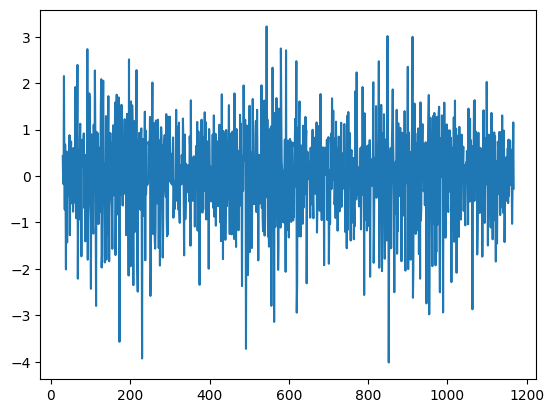

In [124]:
SampleMean = np.mean(TempTransformed2)
SampleVariance = np.std(TempTransformed2)

StdTemp = (TempTransformed2-SampleMean)/SampleVariance
StdTemp = StdTemp.dropna()

plt.plot(StdTemp)
plt.show

## Implemnting the Hidden Markov Model

- The number of states i have chosen is 3 folowing Hot, Cold, Normal regimes 
- Using the hmmlearn package

In [125]:
from hmmlearn.hmm import GaussianHMM

# Define the final time series after transformations
x = StdTemp.values.reshape(-1,1)
# Fitting the HMM

WeatherModel = GaussianHMM(n_components=3,covariance_type="full",n_iter=100)
WeatherModel.fit(x)

# Infering the hidden states and developing the transition matrix
States = WeatherModel.predict(x)
print(States)
print(WeatherModel.transmat_)

# Emission parameters
print(WeatherModel.means_)
print(WeatherModel.covars_)
# Check validity of a three state model

# Build function to undo transformations applied after next temp is predicted
# Cannot cleanly recover data
def UndoTrans(PredictedTemp,SampleMean,SampleVariance):
    # undo standardisation 
    PredictedTemp = PredictedTemp*SampleVariance + SampleMean
    # undo first diffrence


[2 2 2 ... 2 2 2]
[[0.52771002 0.46873946 0.00355052]
 [0.00714701 0.14570328 0.84714971]
 [0.10822881 0.00251893 0.88925225]]
[[ 0.61081129]
 [-1.63201448]
 [ 0.07028408]]
[[[0.89158802]]

 [[0.77460751]]

 [[0.61854309]]]
